# Phenotype clustering
bootstrapped optimization of the number (k) of classes
modified code

positivo: RESUL_PCR_==1 | RESUL_NS1==1 | RESUL_VI_N ==1 | IMUNOH_N==1  | HISTOPA_N ==1? além de SOROTIPO!=None
negativo: RESUL_PCR_==2 | RESUL_NS1==2

(DT_PCR - DT_SIN_PRI) ≤ 7 dias
(DT_NS1 - DT_SIN_PRI) ≤ 7 dias

In [1]:
import pandas as pd
import numpy as np
df=pd.read_parquet('./data/treated/data_SinanDengue_2019_treated_part2.parquet', engine='fastparquet')

In [2]:
varList0=['fever', 'mialgya', 'headache','rash',   'vomiting','nausea','backpain','conjuntivitis',
    'petechiae','Arthralgia_Arthritis',    'torniquete test','retro-orbital pain']
varList=['fever', 'mialgya', 'headache','rash',   'vomiting','nausea','backpain','conjuntivitis',
    'petechiae','Arthralgia_Arthritis',    'torniquete test','retro-orbital pain']

In [3]:
df['PCR_time']=df.DT_PCR-df.DT_SIN_PRI
df['NS1_time']=df.DT_NS1-df.DT_SIN_PRI

In [4]:
df['NS1_time_7'] = np.where(df['NS1_time'] < pd.Timedelta(days=7), 1, 0)
df['PCR_time_7'] = np.where(df['PCR_time'] < pd.Timedelta(days=7), 1, 0)

In [5]:
df['PCR_check']=[r if t==1 else np.nan for r,t in zip(df.RESUL_PCR_,df.PCR_time_7) ]
df['NS1_check']=[r if t==1 else np.nan for r,t in zip(df.RESUL_NS1,df.NS1_time_7) ]

In [6]:
df[['NS1_time_7','NS1_check','NS1_time','DT_NS1','RESUL_NS1','DT_SIN_PRI']]

,NS1_time_7,NS1_check,NS1_time,DT_NS1,RESUL_NS1,DT_SIN_PRI
0,0,NaN,NaT,NaT,NaN,2019-01-01
1,0,NaN,NaT,NaT,NaN,2019-04-01
2,0,NaN,NaT,NaT,NaN,2019-12-12
3,0,NaN,NaT,NaT,NaN,2019-11-14
4,0,NaN,NaT,NaT,NaN,2019-09-21
...,...,...,...,...,...,...
2261951,0,NaN,NaT,NaT,NaN,2019-09-17
2261952,0,NaN,NaT,NaT,NaN,2019-10-15
2261953,0,NaN,NaT,NaT,NaN,2019-09-18
2261954,0,NaN,NaT,NaT,NaN,2019-09-19


In [7]:
# 1 for dengue investigation (independent of result)  np.nan for no dengue inv
df['Dengue_inv']=[1 if (p in [0,1] or n in [0,1] or v ==1 or i==1  or h ==1 or s!=None) else np.nan  for p,n,v,i,h,s in 
                  zip(df.PCR_check, df.NS1_check, df.RESUL_VI_N ,df.IMUNOH_N, df.HISTOPA_N,df.SOROTIPO)  ]
df['Dengue_inv'].value_counts(dropna=False)

Dengue_inv
NaN    1926813
1.0     335143
Name: count, dtype: int64

In [8]:
pd.crosstab(df.SOROTIPO,df.Dengue_inv,dropna=False)

Dengue_inv,1.0,NaN
SOROTIPO,,
Serotype 1,4245,0
Serotype 2,8027,0
Serotype 3,10,0
Serotype 4,400,0
NaN,322461,1926813


In [9]:
df['Dengue_vir']=[0 if (p==0 or n==0) else np.nan for p,n,v,i,h,s in 
                  zip(df.PCR_check, df.NS1_check, df.RESUL_VI_N ,df.IMUNOH_N, df.HISTOPA_N,df.SOROTIPO)  ]

In [10]:
df['Dengue_vir'].value_counts(dropna=False)

Dengue_vir
NaN    2039893
0.0     222063
Name: count, dtype: int64

In [11]:
df['Dengue_vir']=[1 if (p==1 or n==1 or v ==1 or i==1  or h ==1 or s!=None) else d  for p,n,v,i,h,s,d in 
                  zip(df.PCR_check, df.NS1_check, df.RESUL_VI_N ,df.IMUNOH_N, df.HISTOPA_N,df.SOROTIPO,df.Dengue_vir)  ]

In [12]:
df['Dengue_vir'].value_counts(dropna=False)

Dengue_vir
NaN    1926813
0.0     220367
1.0     114776
Name: count, dtype: int64

In [13]:
df3=df.dropna(subset=varList0,how='any')
df3=df3.loc[df3.AGE<16]
df3=df3.loc[df3.time_notif<7]
df3.shape


(352775, 139)

In [14]:
df3=df3.dropna(subset=['Dengue_inv'],axis=0)
df3.shape

(73030, 139)

In [15]:
import pickle
with open('./data/treated/child_1Wk_DengueInv.pkl', 'wb') as file:
    pickle.dump(df3, file)
    pickle.dump(varList, file)

## bootstrapper 

In [16]:
import sys
sys.path.append('./code')
from AdjGridSearch3 import gridSearch

Testing 2 classes...
Testing 3 classes...
Testing 4 classes...
Testing 5 classes...


C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Testing 6 classes...
Testing 7 classes...
Testing 8 classes...
Testing 9 classes...
Testing 10 classes...


C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Testing 11 classes...


...

Testing 13 classes...


C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Testing 14 classes...


C:\Users\tomoe\miniconda3\envs\2507DenguePy\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


    ncomp  npar      n  convergence                   LL   dof  \
0       3    38  73030         True  -356499.24706928746  4070   
1       4    51  73030         True   -351641.3702800933  4069   
2       5    64  73030        False   -350312.3746376012  4068   
3       6    77  73030         True  -349254.93509347783  4067   
4       7    90  73030         True   -348671.6704069347  4066   
5       8   103  73030         True  -348257.39774008945  4065   
6       9   116  73030         True   -348035.1429089104  4064   
7      10   129  73030        False    -347835.855489265  4063   
8      11   142  73030        False  -347701.42992716545  4062   
9      12   155  73030        False   -347657.0862904521  4061   
10     13   168  73030        False  -347503.67148437566  4060   
11     14   181  73030        False  -347454.52933851804  4059   

    log-likelihood diff  dof diff        p value                aic  \
0           9395.797478         1   0.000000e+00  713074.4941385749   

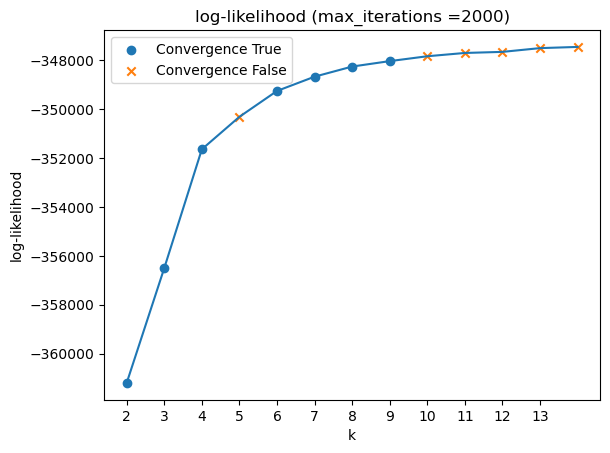

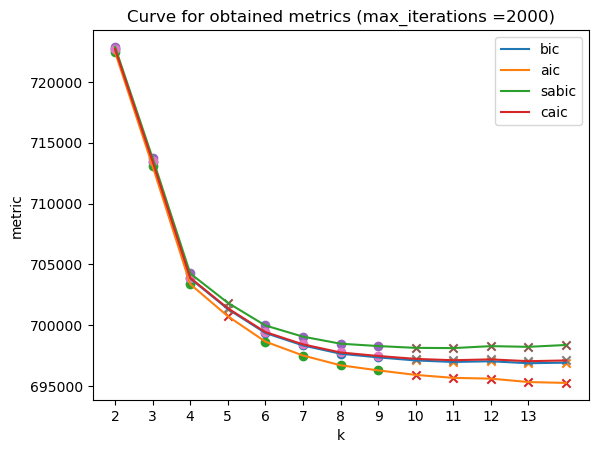

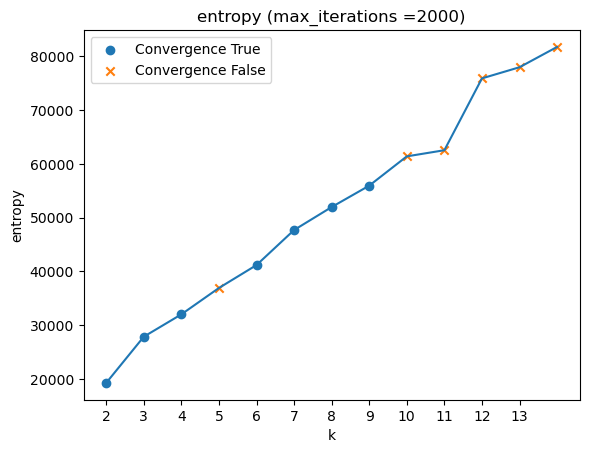

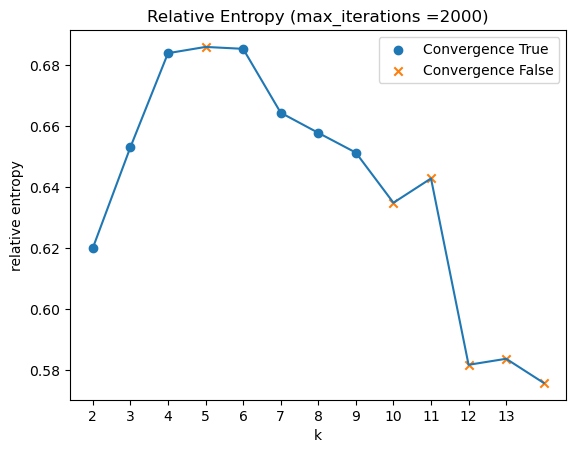

In [17]:
import pickle
from stepmix.stepmix import StepMix
min_k=2
max_k=15

# Define base model
model = StepMix(n_components=3, n_steps=1, measurement='bernoulli',max_iter=2000,
                structural='gaussian_unit', random_state=30, verbose=0, progress_bar=0)

# conduct the search - for now, not exactly a grid search... 
stats, obj_list = gridSearch(model, df3.loc[:,varList],low=min_k, high=max_k)

#store object for future reference
with open('./res/stepMix_gs/gs3_lca_3_15_max2000.pkl', 'wb') as file:
    pickle.dump(stats, file)
    pickle.dump(obj_list, file)

# store files
